In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

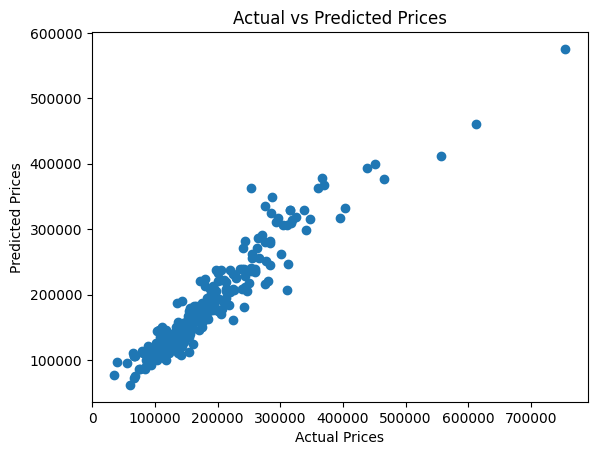

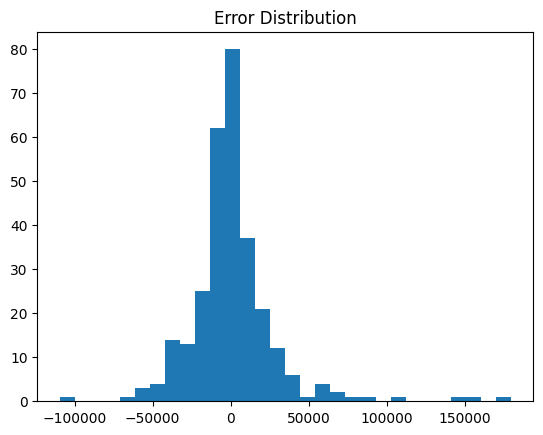

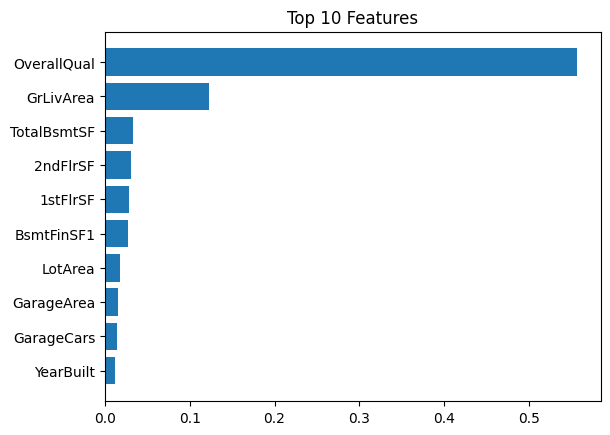

Model saved successfully


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 2. DATA LOADING
# =========================
data = pd.read_csv("dataset/train.csv")

print(data.head())

# =========================
# 3. PREPROCESSING
# =========================

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

y = data["SalePrice"]
X = data.drop(["SalePrice", "Id"], axis=1)

X = pd.get_dummies(X, drop_first=True)

# =========================
# 4. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. MODEL TRAINING
# =========================
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# =========================
# 6. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 7. EVALUATION
# =========================
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# =========================
# 8. GRAPH VISUALIZATION
# =========================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# Error distribution
errors = y_test - y_pred
plt.figure()
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()

# Feature importance
importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top 10 Features")
plt.show()

# =========================
# 9. SAVE MODEL
# =========================
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully")

In [ ]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully")

Model saved successfully


In [ ]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>